# The Articulation Story — §4.1–4.3 (v4)

*2026-08-11. Scope = **unsupervised metrics only** (no hotpot/hover/etc. except the supervised-ladder appendix). Four sections, per discussion: **4.1** codability, **4.2** prompt parts, **4.2E** examples, **4.3** scaling laws. Paper-figure replicas and last week's new instruments are folded into their sections. All data is repo-local: `outputs/articulation_story_20260810/` (the 465MB pack), `outputs/analyses/`, `notebooks/data/2026-07-07-osl-multi/`.*

### Glossary

| term | meaning |
|---|---|
| **recovery** | balanced accuracy of a receiver's per-text binary predictions against the reference labels (threshold-free convention: class-balanced, ties dropped) |
| **reference** | 2-voter consensus (llama70b + qwen25-72b, disagreements dropped); channel cells add GLM voters where noted; leave-one-out when a voter is scored |
| **channel / arm** | what the receiver is shown about the construct: `name`, `definition`, `definition_padded` (length control), `explanation`, `dossier`, `dossier_mismatched` (content control), `examples` (flip-selected texts), `examples_mm` (donor-swapped control) |
| **z** | capability index: logit-AUC on a frozen anchor battery (14 executors, 5 families) |
| **construct classes (blind)** | `norm-boundary` / `mechanics` / `other` — blind categorization of the 203 v3sets constructs |
| **units** | atomic requirements decomposed from a metric definition, blind-labeled MECHANICAL / STRUCTURAL_CRAFT / TASTE (3 crews, 6/6 calibration anchors) |
| **PLANTED** | synthetic constructs with known decision rules, used as instrument controls |

### The week's instruments (2026-08-05 → 08-11), where each lives now

| instrument | section | artifact |
|---|---|---|
| three-family saturation census | 4.3d | `analyses/family_verdict_join_v1.json` |
| reference-reliability filter + remedy table | 4.3e | `outputs/analyses/reliability_filter_v1/`, `verdict_table_v1/` |
| de-censor test (frontier vs local) | 4.3f | `analyses/decensor_harvest_v1.json` |
| frontier limit question (gate/gap) | 4.2E-c | `analyses/frontier_limit_humor_v2.json` |
| channel × capability exhibit (LOO refs) | 4.2c | `outputs/analyses/channel_scale_v2/` |
| examples-at-scale two-receiver ledger | 4.2E-b | `analyses/v3sets_ledger_v1.json` |
| MI upper-bound census | 4.3g | `analyses/mi_upper_census_v2.json` |
| ladder validation (P1–P3 prereg) | 4.3h | `outputs/analyses/ladder_p123_v1/` |

In [1]:
import glob, json, os, re, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from scipy import stats as sps
D = "../outputs/articulation_story_20260810"
TASKS = ["humor", "creative_writing", "math", "peer_review", "news_homepages"]
ZTASKS = ["humor", "creative_writing", "math", "peer_review"]   # zxa-channel tasks (news excluded from joins)
RCOL = {"RISING": "#b03a2e", "REACHES": "#2c5aa0", "BOUNDED": "#ca6f1e", "NOISY": "0.6"}
def lp(p):
    if not os.path.exists(p): return {}
    z = np.load(p, allow_pickle=True)
    return {str(n): z["m_bar"][i] for i, n in enumerate([str(x) for x in z["names"]])}
def balanced(pred, lab):
    ok = (lab >= 0) & np.isfinite(pred)
    if ok.sum() < 30: return None
    p = (pred[ok] > .5).astype(int); l = lab[ok]
    accs = [float(np.mean(p[l == c] == c)) for c in (0, 1) if (l == c).sum() >= 5]
    return float(np.mean(accs)) if len(accs) == 2 else None
_rng = np.random.default_rng(0)
def ci20(d):
    d = np.asarray([x for x in d if x is not None and np.isfinite(x)], float)
    bm = d[_rng.integers(0, len(d), size=(20000, len(d)))].mean(1)
    return d.mean(), np.percentile(bm, 2.5), np.percentile(bm, 97.5)
# family split for receiver panels (never connect a line across families)
FAMS = {"llama": ["llama1b", "llama3b", "llama8b", "llama70b"],
        "qwen2.5": ["qwen25-3b", "qwen25-7b", "qwen25-14b", "qwen25-32b", "qwen25-72b"],
        "(isolated)": ["mistral7b", "gemma2-27b", "phi4", "gpt-oss-120b"]}
FCOL = {"llama": "#2c5aa0", "qwen2.5": "#b03a2e", "(isolated)": "0.45"}

## 4.1 Codability — what fraction of each metric's requirements can code check?

Each of the 1,032 bank definitions was decomposed into atomic **units** (3,458 total) and each unit blind-labeled `MECHANICAL` (a deterministic program could check it) / `STRUCTURAL_CRAFT` / `TASTE` by three independent crews with 6/6 calibration anchors. A metric's **% codable** = share of its units labeled MECHANICAL.

**Why five tasks (user question 2026-08-11)?** The 1,032-metric universe here is the *crowd-panel bank* — the five tasks where codability can be **joined to transmission measurements** (crowd panels, channel arms, staircases). The full OSL curve universe has **eight** domains (adds notice-and-comment 66, press-releases 199, patents 7 fitted metrics — banks and definitions exist for all of them), but the blind unit-codability labeling has only been run on the five-task bank. Extending it is a ~272-definition labeling wave (3 blind crews + anchors, CPU/agent work, no GPU) — **available on request**; until then the cross-task average below is a 5-task number, and the codability↔scaling join in 4.1b covers those 5 tasks.

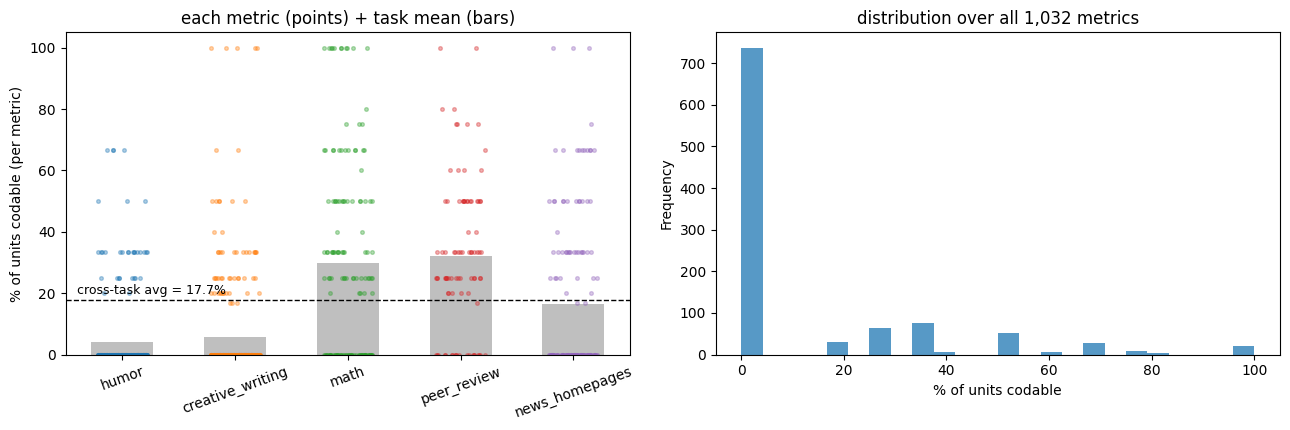

,n_metrics,n_units,mean_pct_codable,pct_fully_uncodable,mean_pct_taste
task,,,,,
humor,284,968,4.2,88.4,30.7
creative_writing,369,1246,5.6,84.8,21.3
math,141,455,29.8,40.4,5.2
peer_review,88,331,32.3,22.7,6.9
news_homepages,150,458,16.4,64.0,10.2


In [2]:
# 4.1a — per-metric % codable: strip (every metric) + task means + distribution.
cod = {}
for t in TASKS:
    d = json.load(open(f"{D}/code_metrics/unit_codability_{t}.json"))["metrics"]
    for name, units in d.items():
        labs = [u["label"] for u in units]
        cod[(t, name)] = {"n_units": len(labs),
                          "pct_codable": 100 * sum(l == "MECHANICAL" for l in labs) / len(labs),
                          "pct_taste": 100 * sum(l == "TASTE" for l in labs) / len(labs)}
dfc = pd.DataFrame([{"task": t, "metric": n, **v} for (t, n), v in cod.items()])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
means = dfc.groupby("task")["pct_codable"].mean().reindex(TASKS)
for i, t in enumerate(TASKS):
    y = dfc[dfc.task == t]["pct_codable"].values
    axes[0].scatter(i + _rng.uniform(-.22, .22, len(y)), y, s=7, alpha=.35)
axes[0].bar(range(len(TASKS)), means.values, width=.55, alpha=.25, color="k", zorder=0)
axes[0].axhline(means.mean(), color="k", ls="--", lw=1)
axes[0].text(-.4, means.mean() + 2, f"cross-task avg = {means.mean():.1f}%", fontsize=9)
axes[0].set_xticks(range(len(TASKS))); axes[0].set_xticklabels(TASKS, rotation=20)
axes[0].set_ylabel("% of units codable (per metric)")
axes[0].set_title("each metric (points) + task mean (bars)")
dfc["pct_codable"].plot(kind="hist", bins=24, ax=axes[1], alpha=.75)
axes[1].set_xlabel("% of units codable"); axes[1].set_title("distribution over all 1,032 metrics")
plt.tight_layout(); plt.show()
display(dfc.groupby("task").agg(n_metrics=("metric", "count"), n_units=("n_units", "sum"),
        mean_pct_codable=("pct_codable", "mean"),
        pct_fully_uncodable=("pct_codable", lambda s: 100 * (s == 0).mean()),
        mean_pct_taste=("pct_taste", "mean")).round(1).reindex(TASKS))

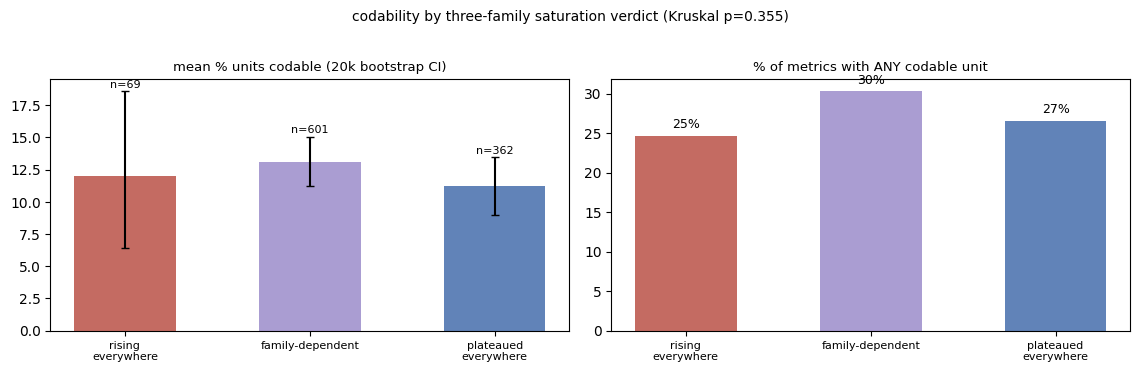

                      mean  median  pct_any_codable
satgroup                                           
family-dependent      13.1     0.0             30.3
plateaued everywhere  11.2     0.0             26.5
rising everywhere     12.0     0.0             24.6


In [3]:
# 4.1b — does codability predict the scaling verdict? (join to 4.3's three-family census)
# NOTE: most metrics have ZERO codable units (medians are 0 in every group), so the medians
# are uninformative — we read MEANS + the share of metrics with ANY codable unit.
FJ = json.load(open(f"{D}/analyses/family_verdict_join_v1.json"))["full_rows"]
def satgroup(r, t=.02):
    tm = [v for v in r["top_minus_mid"].values() if v is not None]
    if len(tm) < 3: return None
    if all(v > t for v in tm): return "rising everywhere"
    if all(v <= t for v in tm): return "plateaued everywhere"
    return "family-dependent"
GROUP = {(r["task"], r["name"]): satgroup(r) for r in FJ}
dfc["satgroup"] = [GROUP.get((t, n)) for t, n in zip(dfc.task, dfc.metric)]
sub = dfc[dfc.satgroup.notna()]
order = ["rising everywhere", "family-dependent", "plateaued everywhere"]
GC = {"rising everywhere": "#b03a2e", "family-dependent": "#8e7cc3", "plateaued everywhere": "#2c5aa0"}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
for i, g in enumerate(order):
    d = sub[sub.satgroup == g]["pct_codable"].values
    m, lo, hi = ci20(d)
    axes[0].bar(i, m, .55, color=GC[g], alpha=.75)
    axes[0].errorbar(i, m, yerr=[[m - lo], [hi - m]], color="k", capsize=3)
    axes[0].text(i, hi + .3, f"n={len(d)}", ha="center", fontsize=8)
    axes[1].bar(i, 100 * np.mean(d > 0), .55, color=GC[g], alpha=.75)
    axes[1].text(i, 100 * np.mean(d > 0) + 1, f"{100*np.mean(d>0):.0f}%", ha="center", fontsize=9)
for ax, t_ in zip(axes, ("mean % units codable (20k bootstrap CI)", "% of metrics with ANY codable unit")):
    ax.set_xticks(range(len(order))); ax.set_xticklabels([g.replace(" ", "\n") for g in order], fontsize=8)
    ax.set_title(t_, fontsize=9.5)
kw = sps.kruskal(*[sub[sub.satgroup == g]["pct_codable"].values for g in order])
plt.suptitle(f"codability by three-family saturation verdict (Kruskal p={kw.pvalue:.3g})", y=1.02, fontsize=10)
plt.tight_layout(); plt.show()
print(sub.groupby("satgroup")["pct_codable"].agg(["mean", "median", lambda s: 100*(s>0).mean()])
      .rename(columns={"<lambda_0>": "pct_any_codable"}).round(1))

## 4.2 Prompt parts — which text segments carry the construct?

**Arms** (all at receiver = llama70b; reference = multi-voter consensus on the dossier arm): `name` → `definition` → `definition_padded` (same length as explanation, no new content — the length control) → `explanation` (adds mechanism) → `dossier` (everything) → `dossier_mismatched` (a *different* construct's dossier — the content control). **Scope**: all six arms exist only for the 41-base authored slate (n=32 after reference requirements) — 4.2a/b are slate-scale; 4.2c is the full-bank view (rubric + examples channels, 284 humor constructs). Channels are **categories, not a continuum**, so everything here is box/strip plots (per user 2026-08-11); the old connected-line version is retired.

Presentation: (a) distribution per arm; (b) paired *gains over bare name*; (c) **where the mean hides structure** — per-metric winning arm and the metrics where the ordering inverts; (d) the capability interaction (channel × receiver, family-split).

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_57488/2108168059.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data, labels=ARMS, showfliers=False, patch_artist=True)


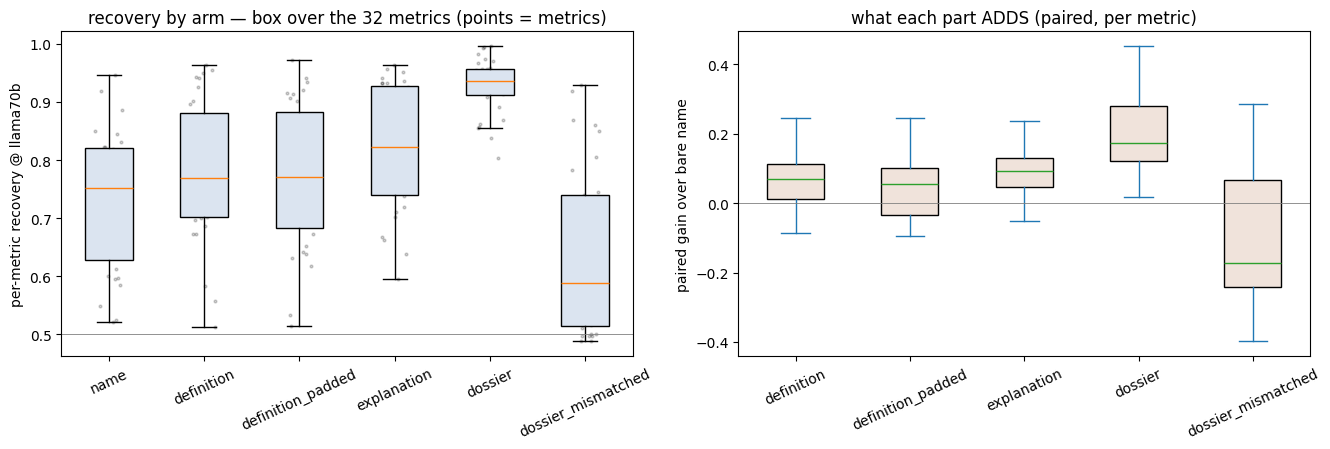

definition             gain over name = +0.056  CI[+0.021,+0.088]  n=32
definition_padded      gain over name = +0.037  CI[+0.003,+0.070]  n=32
explanation            gain over name = +0.088  CI[+0.054,+0.122]  n=32
dossier                gain over name = +0.197  CI[+0.158,+0.237]  n=32
dossier_mismatched     gain over name = -0.093  CI[-0.158,-0.025]  n=32


In [4]:
# 4.2a — per-arm recovery distributions + paired gain-over-name boxes (llama70b receiver).
LADDER = ["llama1b","llama3b","qwen25-3b","qwen25-7b","llama8b","qwen25-14b",
          "gemma2-27b","qwen25-32b","llama70b","qwen25-72b"]
PAN = {t: {ex: lp(f"{D}/zxa_panels/mbar_zxa_{t}_{ex}.npz") for ex in LADDER} for t in ZTASKS}
GLMP = {t: {g: lp(f"{D}/zxa_panels/mbar_zxaglm_{t}_{g}.npz") for g in ("glm-47","glm-52")} for t in ZTASKS}
def ref_for(task, base):
    votes = []
    for src in (PAN[task].get("llama70b", {}), PAN[task].get("qwen25-72b", {}),
                GLMP[task].get("glm-47", {}), GLMP[task].get("glm-52", {})):
        r = src.get(base + "||dossier")
        if r is not None: votes.append((np.asarray(r, float) > .5).astype(float))
    if len(votes) < 2: return None
    m = np.nanmean(np.stack(votes), 0)
    return np.where(m > .5, 1, np.where(m < .5, 0, -1))
ARMS = ["name", "definition", "definition_padded", "explanation", "dossier", "dossier_mismatched"]
recs = []
for t in ZTASKS:
    bases = sorted({k.split("||")[0] for k in PAN[t].get("llama70b", {}) if not k.startswith("PLANTED")})
    for b in bases:
        lab = ref_for(t, b)
        if lab is None: continue
        row = {"task": t, "metric": b}
        for arm in ARMS:
            r = PAN[t]["llama70b"].get(f"{b}||{arm}")
            if r is not None:
                y = balanced(np.asarray(r, float), lab)
                if y is not None: row[arm] = y
        if "name" in row and "dossier" in row: recs.append(row)
df42 = pd.DataFrame(recs)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
data = [df42[a].dropna().values for a in ARMS]
bp = axes[0].boxplot(data, labels=ARMS, showfliers=False, patch_artist=True)
for p in bp["boxes"]: p.set_facecolor("#dbe4f0")
for i, d in enumerate(data):
    axes[0].scatter(1 + i + _rng.uniform(-.15, .15, len(d)), d, s=4, alpha=.18, color="k")
axes[0].axhline(.5, color="gray", lw=.6); axes[0].tick_params(axis="x", rotation=25)
axes[0].set_ylabel("per-metric recovery @ llama70b")
axes[0].set_title(f"recovery by arm — box over the {len(df42)} metrics (points = metrics)")
gains = df42[["definition","definition_padded","explanation","dossier","dossier_mismatched"]].sub(df42["name"], axis=0)
bp = gains.plot(kind="box", ax=axes[1], rot=25, showfliers=False, patch_artist=True,
                boxprops=dict(facecolor="#f0e3db"))
axes[1].axhline(0, color="gray", lw=.6); axes[1].set_ylabel("paired gain over bare name")
axes[1].set_title("what each part ADDS (paired, per metric)")
plt.tight_layout(); plt.show()
for a in ARMS[1:]:
    m, lo, hi = ci20((df42[a] - df42["name"]).dropna().values)
    print(f"{a:22s} gain over name = {m:+.3f}  CI[{lo:+.3f},{hi:+.3f}]  n={df42[a].notna().sum()}")

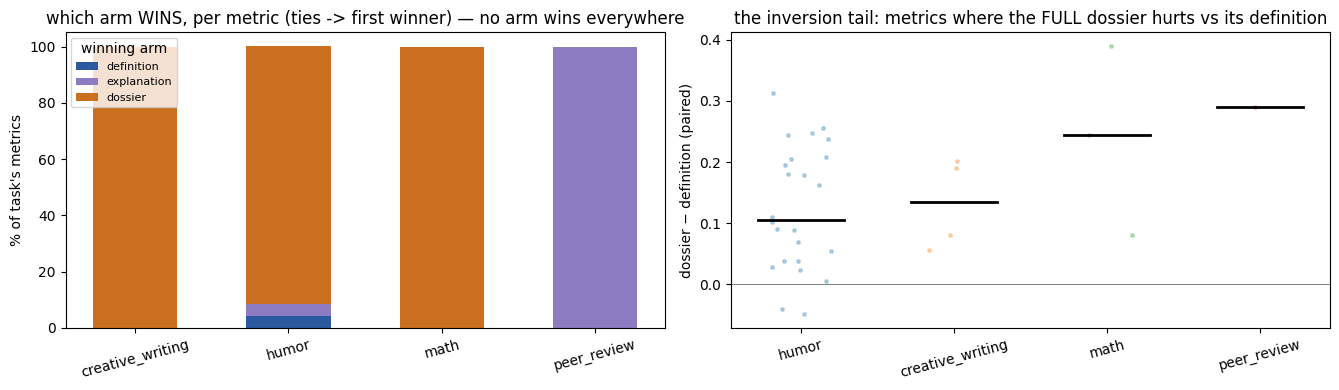

2/32 metrics lose >= .03 going definition -> dossier (more text hurts):


,task,metric,definition,dossier,dossier_minus_def
1,humor,Balancing humor with pathos,0.963,0.914,-0.049
19,humor,Self‑deprecation and willingness to be embarra...,0.896,0.856,-0.040


In [5]:
# 4.2b — where the single mean hides structure: winning arm per metric, per task; and the
# inversion tail (metrics where MORE text HURTS).
CORE = ["name", "definition", "explanation", "dossier"]
sub = df42.dropna(subset=CORE).copy()
sub["winner"] = sub[CORE].idxmax(axis=1)
tab = pd.crosstab(sub.task, sub.winner, normalize="index").mul(100).round(1)
tab = tab[[c for c in CORE if c in tab.columns]]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4))
bot = np.zeros(len(tab))
WCOL = {"name": "#9aa7b1", "definition": "#2c5aa0", "explanation": "#8e7cc3", "dossier": "#ca6f1e"}
for c in tab.columns:
    axes[0].bar(range(len(tab)), tab[c], .55, bottom=bot, color=WCOL[c], label=c)
    bot += tab[c].values
axes[0].set_xticks(range(len(tab))); axes[0].set_xticklabels(tab.index, rotation=15)
axes[0].set_ylabel("% of task's metrics"); axes[0].legend(fontsize=8, title="winning arm")
axes[0].set_title("which arm WINS, per metric (ties -> first winner) — no arm wins everywhere")
sub["dossier_minus_def"] = sub["dossier"] - sub["definition"]
for i, t in enumerate(ZTASKS):
    y = sub[sub.task == t]["dossier_minus_def"].values
    axes[1].scatter(i + _rng.uniform(-.2, .2, len(y)), y, s=6, alpha=.3)
    axes[1].plot([i - .28, i + .28], [np.median(y)] * 2, color="k", lw=2)
axes[1].axhline(0, color="gray", lw=.7)
axes[1].set_xticks(range(len(ZTASKS))); axes[1].set_xticklabels(ZTASKS, rotation=15)
axes[1].set_ylabel("dossier − definition (paired)")
axes[1].set_title("the inversion tail: metrics where the FULL dossier hurts vs its definition")
plt.tight_layout(); plt.show()
inv = sub[sub.dossier_minus_def < -.03].sort_values("dossier_minus_def")
print(f"{len(inv)}/{len(sub)} metrics lose >= .03 going definition -> dossier (more text hurts):")
display(inv[["task", "metric", "definition", "dossier", "dossier_minus_def"]].head(12).round(3))

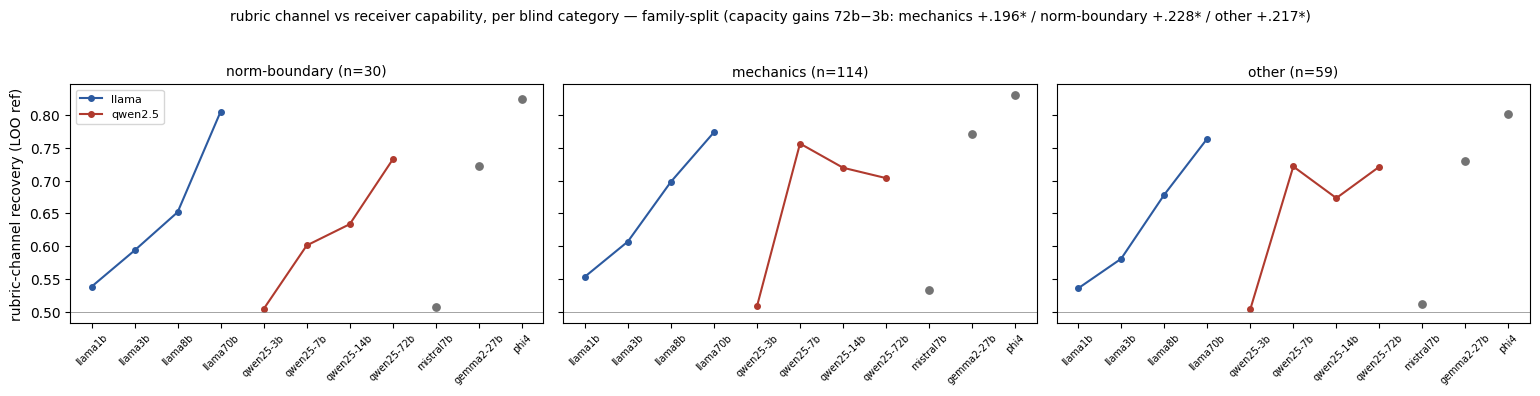

Norm-boundary constructs start LOWER and climb LONGER — they catch up only at 72b.
DISCLOSED: explanation/dossier channels: slate-only (41 bases)
DISCLOSED: thinking channel: slate x qwen3 rungs only
DISCLOSED: 'units' channel: no construct-side scored instrument; 4.1 unit decomposition is definitional (codability), not a channel score
DISCLOSED: name channel at bank: llama70b holdout only


In [6]:
# 4.2c — channel x capability at bank scale (exhibit v2, LOO refs): rubric-channel recovery
# per blind construct category, drawn FAMILY-SPLIT (a line never crosses families).
CH = json.load(open("../outputs/analyses/channel_scale_v2/channel_scale_v2.json"))
fig, axes = plt.subplots(1, 3, figsize=(15.5, 3.8), sharey=True)
cats = ["norm-boundary", "mechanics", "other"]
for ax, g in zip(axes, cats):
    curve = CH["bank_rubric_curves"]["category"].get(g, {})
    for fam, exes in FAMS.items():
        pts = [(ex, curve[ex]["mean"]) for ex in exes if curve.get(ex)]
        if not pts: continue
        if fam == "(isolated)":
            for ex, y in pts:
                ax.scatter([ex], [y], color=FCOL[fam], s=28, zorder=3)
        else:
            ax.plot([p[0] for p in pts], [p[1] for p in pts], "-o", ms=4,
                    color=FCOL[fam], label=fam)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    n = max(curve[ex]["n"] for ex in curve if curve.get(ex))
    ax.set_title(f"{g} (n={n})", fontsize=10); ax.axhline(.5, color="gray", lw=.5)
axes[0].set_ylabel("rubric-channel recovery (LOO ref)"); axes[0].legend(fontsize=8)
plt.suptitle("rubric channel vs receiver capability, per blind category — family-split "
             "(capacity gains 72b−3b: mechanics +.196* / norm-boundary +.228* / other +.217*)", y=1.03, fontsize=10)
plt.tight_layout(); plt.show()
print("Norm-boundary constructs start LOWER and climb LONGER — they catch up only at 72b.")
for note in CH["coverage_disclosures"]: print("DISCLOSED:", note)

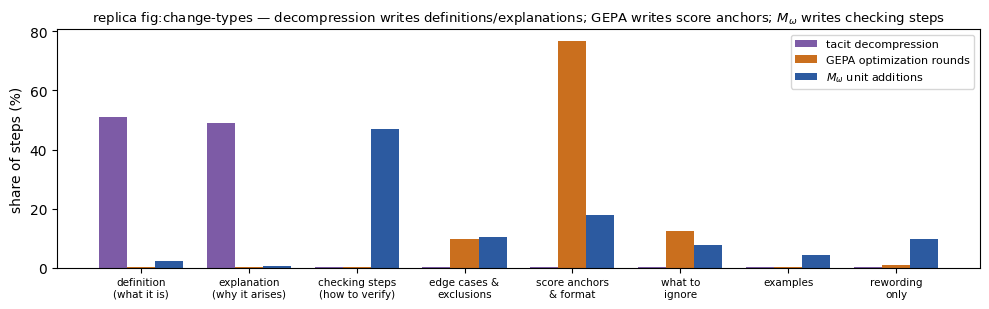

In [7]:
# 4.2d — what each improvement PROCESS writes into the prompt (replica of the paper's
# change-types figure; paper-exact values parsed from the AUTO-GENERATED TikZ, since the
# label scratchpad expired; HB174-certified labels, two-pass kappa .68/.93).
TEX = open("../latex/paper-2__articulation-upper-bounds/figs/gen_change_types.tex").read()
FILLS = {"violet!25": "tacit decompression", "orange!35": "GEPA optimization rounds",
         "blue!30": "$M_\\omega$ unit additions"}
bars = re.findall(r"\\fill\[(violet!25|orange!35|blue!30)[^\]]*\] \(([\d.]+),0\) rectangle \(([\d.]+),([\d.]+)\);", TEX)
CATS = ["definition\n(what it is)", "explanation\n(why it arises)", "checking steps\n(how to verify)",
        "edge cases &\nexclusions", "score anchors\n& format", "what to\nignore", "examples", "rewording\nonly"]
series = {v: [] for v in FILLS.values()}
for fill, x0, x1, h in bars:
    series[FILLS[fill]].append(float(h) / 3.1 * 100)
fig, ax = plt.subplots(figsize=(10, 3.2))
w = 0.26
SCOL = {"tacit decompression": "#7d5ba6", "GEPA optimization rounds": "#ca6f1e",
        "$M_\\omega$ unit additions": "#2c5aa0"}
for j, (nm, vals) in enumerate(series.items()):
    ax.bar(np.arange(len(CATS)) + (j - 1) * w, vals[:len(CATS)], w, color=SCOL[nm], label=nm)
ax.set_xticks(range(len(CATS))); ax.set_xticklabels(CATS, fontsize=7.5)
ax.set_ylabel("share of steps (%)"); ax.legend(fontsize=8)
ax.set_title("replica fig:change-types — decompression writes definitions/explanations; GEPA writes score anchors; $M_\\omega$ writes checking steps", fontsize=9.5)
plt.tight_layout(); plt.show()

## 4.2E Examples — when does *showing* beat *telling*?

The examples channel: per construct, a **flip-selected** set of texts (chosen because relabeling them most changes the construct's extension) is shown in place of / beside the definition. Every claim carries the **donor-swap control** (`examples_mm` = another construct's examples): `examples − examples_mm` = construct-specific **CONTENT**; `examples_mm − definition` = generic **ANCHORING** (re-calibration any examples provide).

Three exhibits: (a) the per-metric ledger and where examples beat definitions across three judges; (b) the two-receiver decomposition at bank scale + which construct class carries the content; (c) the frontier limit question.

metrics where examples beat the definition by >= .05 (best cell per metric):


,task,judge,definition,examples,delta
metric,,,,,
"Compressed, quotable phrasing",humor,llama70b,0.5511,0.8114,0.260
"Surprise, misdirection, and dual‑read clarity",humor,llama70b,0.6706,0.9059,0.235
"Delivery, timing, and commitment",humor,qwen25-72b,0.7361,0.9618,0.226
"Surprise, incongruity, and misdirection mechanics",humor,llama70b,0.6791,0.9002,0.221
Economy and Precision of Prose,creative_writing,llama70b,0.5718,0.7719,0.200
Observational/everyday‑life humor,humor,llama70b,0.6808,0.8808,0.200
Shared knowledge and reference accessibility,humor,qwen25-72b,0.5728,0.7529,0.180
Concrete imagery and vivid specificity,humor,llama70b,0.7491,0.9239,0.175
Cringe/awkwardness calibrated,humor,llama70b,0.7751,0.9234,0.148


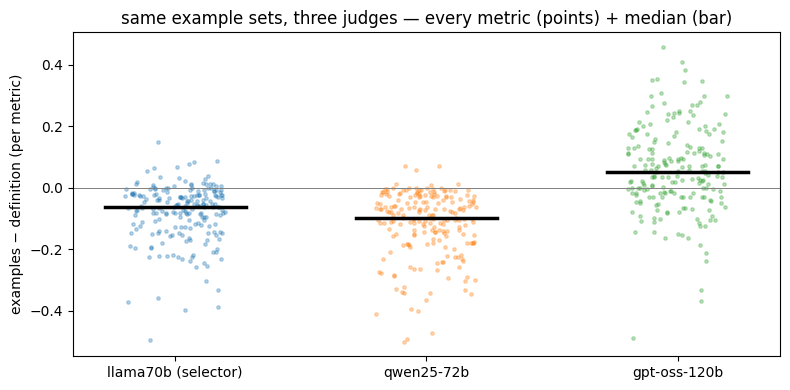

In [8]:
# 4.2E-a — examples vs definition per metric, three judges (strip + median; categorical -> no lines).
led70 = []
for s in ("llama70b", "qwen25-72b"):
    d = json.load(open(f"{D}/flips/flip_functional_v2_{s}.json"))["results"]
    for task, dd in d.items():
        if task == "news_homepages": continue     # probe-universe landmine: news joins retracted
        for base, rec in dd.items():
            for obj, po in rec.get("objectives", {}).items():
                if obj == "null": continue
                h = po.get("holdout", {})
                if h.get("functional") is not None and h.get("definition") is not None:
                    led70.append({"task": task, "metric": base, "judge": s,
                                  "definition": h["definition"], "examples": h["functional"],
                                  "delta": round(h["functional"] - h["definition"], 3)})
df70 = pd.DataFrame(led70)
best = (df70.sort_values("delta", ascending=False).groupby("metric").first()
        .sort_values("delta", ascending=False))
print("metrics where examples beat the definition by >= .05 (best cell per metric):")
display(best[best.delta >= .05][["task", "judge", "definition", "examples", "delta"]])
led = json.load(open(f"{D}/analyses/v3sets_ledger_v1.json"))
rows = []
for rcv in ("qwen25-72b", "gpt-oss-120b"):
    for r in led[rcv]:
        rows.append({"judge": rcv, "metric": r["b"],
                     "examples_minus_definition": r["functional"] - r["definition"]})
v3h = json.load(open(f"{D}/flips/flip_functional_v3_llama70b.json"))["results"]["humor"]
for b, rec in v3h.items():
    h = rec["objectives"].get("frontier2v", {}).get("holdout", {})
    if h.get("functional") is not None and h.get("definition") is not None:
        rows.append({"judge": "llama70b (selector)", "metric": b,
                     "examples_minus_definition": h["functional"] - h["definition"]})
dfr = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8, 4))
order = ["llama70b (selector)", "qwen25-72b", "gpt-oss-120b"]
for i, j in enumerate(order):
    y = dfr[dfr.judge == j]["examples_minus_definition"].values
    ax.scatter(i + _rng.uniform(-.2, .2, len(y)), y, s=6, alpha=.3)
    ax.plot([i - .28, i + .28], [np.median(y)] * 2, color="k", lw=2.5)
ax.axhline(0, color="gray", lw=.7); ax.set_xticks(range(3)); ax.set_xticklabels(order)
ax.set_ylabel("examples − definition (per metric)")
ax.set_title("same example sets, three judges — every metric (points) + median (bar)")
plt.tight_layout(); plt.show()

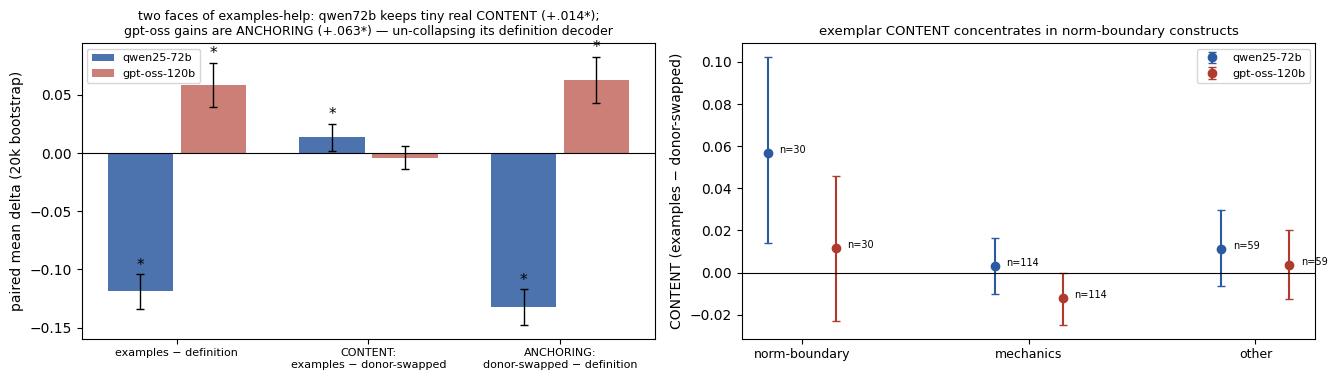

In [9]:
# 4.2E-b — the two-receiver decomposition at bank scale (203 paired sets) + where the
# CONTENT lives (blind categories; recorded rank tests p=.006 qwen / .0095 avg, LOO-robust).
CAT = json.load(open(f"{D}/analyses/metric_categories_blind_v1.json"))
CONTRASTS = [("examples − definition", lambda r: r["functional"] - r["definition"]),
             ("CONTENT:\nexamples − donor-swapped", lambda r: r["functional"] - r["functionalmm"]),
             ("ANCHORING:\ndonor-swapped − definition", lambda r: r["functionalmm"] - r["definition"])]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.9))
w = 0.38
for j, rcv in enumerate(["qwen25-72b", "gpt-oss-120b"]):
    rows = led[rcv]
    for i, (nm, fn) in enumerate(CONTRASTS):
        m, lo, hi = ci20([fn(r) for r in rows])
        star = lo > 0 or hi < 0
        axes[0].bar(i + (j - .5) * w, m, w * .9, color=["#2c5aa0", "#b03a2e"][j],
                    alpha=.85 if j == 0 else .65, label=rcv if i == 0 else None)
        axes[0].errorbar(i + (j - .5) * w, m, yerr=[[m - lo], [hi - m]], color="k", capsize=3, lw=1)
        axes[0].text(i + (j - .5) * w, hi + .004, "*" if star else "", ha="center", fontsize=11)
axes[0].axhline(0, color="k", lw=.8)
axes[0].set_xticks(range(3)); axes[0].set_xticklabels([c[0] for c in CONTRASTS], fontsize=8)
axes[0].legend(fontsize=8); axes[0].set_ylabel("paired mean delta (20k bootstrap)")
axes[0].set_title("two faces of examples-help: qwen72b keeps tiny real CONTENT (+.014*);\ngpt-oss gains are ANCHORING (+.063*) — un-collapsing its definition decoder", fontsize=9)
cats = ["norm-boundary", "mechanics", "other"]
for j, rcv in enumerate(["qwen25-72b", "gpt-oss-120b"]):
    rows = led[rcv]
    for i, c in enumerate(cats):
        vals = [r["functional"] - r["functionalmm"] for r in rows if CAT.get(r["b"]) == c]
        if not vals: continue
        m, lo, hi = ci20(vals)
        axes[1].errorbar(i + (j - .5) * .3, m, yerr=[[m - lo], [hi - m]], fmt="o",
                         color=["#2c5aa0", "#b03a2e"][j], capsize=3, label=rcv if i == 0 else None)
        axes[1].text(i + (j - .5) * .3 + .05, m, f"n={len(vals)}", fontsize=7)
axes[1].axhline(0, color="k", lw=.8)
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(cats, fontsize=9)
axes[1].legend(fontsize=8); axes[1].set_ylabel("CONTENT (examples − donor-swapped)")
axes[1].set_title("exemplar CONTENT concentrates in norm-boundary constructs", fontsize=9.5)
plt.tight_layout(); plt.show()

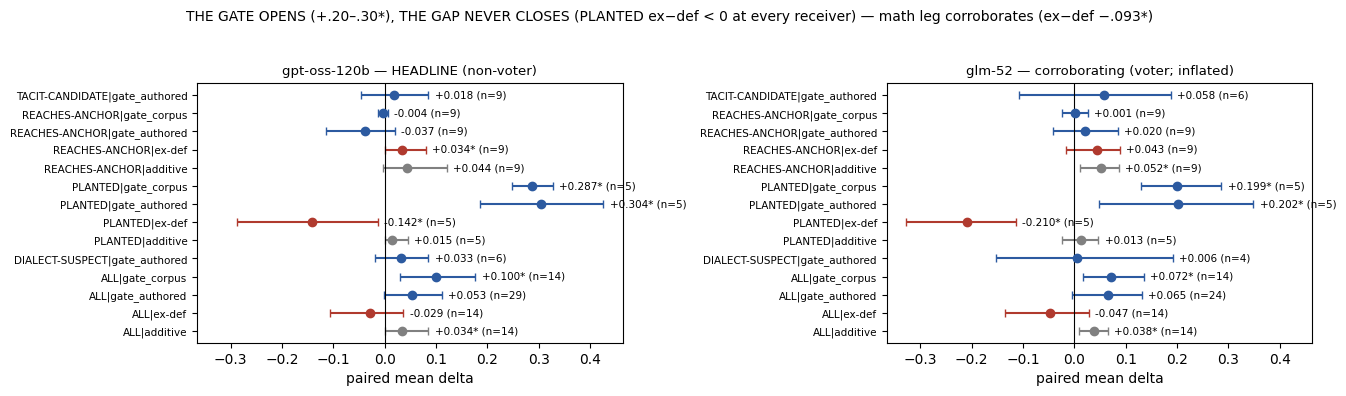

In [10]:
# 4.2E-c — the limit question (criterion 3): PLANTED tacit constructs at the frontier.
# gpt-oss-120b = HEADLINE (non-voter, clean); GLM-5.2 corroborates but is a reference
# voter (circularity inflates its deltas — disclosed).
FL = json.load(open(f"{D}/analyses/frontier_limit_humor_v2.json"))["receivers"]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.8), sharex=True)
for ax, rcv in zip(axes, ["gpt-oss-120b", "glm-52"]):
    con = FL[rcv]["contrasts"]
    keys = sorted(con.keys())
    for i, k in enumerate(keys):
        c = con[k]
        col = "#b03a2e" if "ex-def" in k else ("#2c5aa0" if "gate" in k else "0.5")
        ax.errorbar(c["mean"], i, xerr=[[c["mean"] - c["ci"][0]], [c["ci"][1] - c["mean"]]],
                    fmt="o", color=col, capsize=3)
        star = "*" if c["ci"][0] > 0 or c["ci"][1] < 0 else ""
        ax.text(c["ci"][1] + .012, i, f"{c['mean']:+.3f}{star} (n={c['n']})", va="center", fontsize=7.5)
    ax.axvline(0, color="k", lw=.8)
    ax.set_yticks(range(len(keys))); ax.set_yticklabels(keys, fontsize=7.5)
    ax.set_title(rcv + (" — HEADLINE (non-voter)" if "oss" in rcv else " — corroborating (voter; inflated)"), fontsize=9.5)
    ax.set_xlabel("paired mean delta")
plt.suptitle("THE GATE OPENS (+.20–.30*), THE GAP NEVER CLOSES (PLANTED ex−def < 0 at every receiver) — math leg corroborates (ex−def −.093*)", y=1.03, fontsize=10)
plt.tight_layout(); plt.show()

## 4.3 Scaling laws — recovery as capability grows

### The definitions, precisely (user question 2026-08-11)

There are **two different taxonomies** in play, from two different instruments. They are related but not the same thing:

**(1) OSL fit verdicts** (`RISING / REACHES / BOUNDED / NOISY`) — per metric, from its 14-executor curve of *disattenuated* recovery $y$ vs capability $z$ (cross-family panel; $y$ divided by $\sqrt{\text{split-half reliability}}$). Fit **both** a 3-parameter logistic $y = L/(1+e^{-k(z-z_0)})$ and a straight line, compare by AICc:

- **`kneed`** := AICc(logistic) < AICc(linear) — the curve shows *statistically preferred curvature* (a bend toward an asymptote) within the observed range.
- **BOUNDED** := kneed **and** the profile-CI upper bound of the fitted ceiling, $L_{hi}$, sits **below the planted-control reference** (what synthetic fully-articulable constructs achieve on the same task; selected by capability, never by outcome). The ceiling is not merely visible — it is certifiably below "articulable."
- **REACHES** := kneed, but $L_{hi}$ is not below the planted reference — the curve bends and attains its ceiling in range, and that ceiling is consistent with full articulability.
- **RISING** := *not* kneed, and Spearman$(z,y) \ge .35$ — a monotone climb with **no detectable curvature**. (99% of rising fits put $L_{hi}>1$: the ceiling is unidentified — "rising" chiefly records censoring by our strongest executor.)
- **NOISY** := neither (excluded from all regime claims).

**So yes — a RISING and a REACHES curve can look nearly identical.** The discriminator is not the level or the visual shape but a *model-selection call on curvature* (AICc), which is exactly the kind of difference the eye can't reliably see at n≈14 points. Exhibit 4.3a below makes this concrete: same metrics, with their fitted logistics and the AICc call drawn on.

**(2) Staircase saturation groups** (`rising everywhere / family-dependent / plateaued everywhere`) — per metric, from three *within-family* staircases (llama, qwen2.5, qwen3): **yes, this one is just a threshold rule** — top rung minus mid rung recovery $> .02$ in **all** families = rising everywhere; $\le .02$ in all = plateaued everywhere; else family-dependent. It is deliberately crude and family-robust: it asks only "does the top of every ladder still buy anything," with no fit, no extrapolation. The fit verdicts extrapolate; the saturation groups don't. When they disagree, the saturation group is the conservative claim.

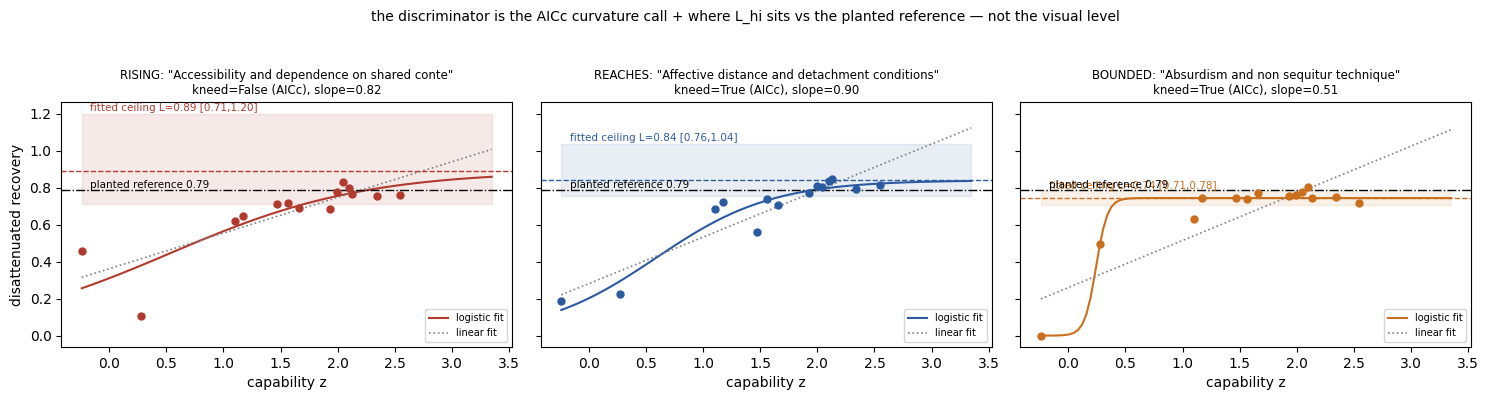

humor bank: verdict x kneed cross-tab: {(True, 'BOUNDED'): 41, (True, 'REACHES'): 114, (False, 'RISING'): 123, (False, 'NOISY'): 6}


In [11]:
# 4.3a — CAN you see RISING vs REACHES? Exemplars with their fits and the AICc call.
from scipy.optimize import curve_fit
laws = {r["name"]: r for r in json.load(open("data/2026-07-07-osl-multi/laws_humor.json"))["rows"]}
ceil_h = json.load(open("data/2026-07-07-osl-multi/laws_humor.json"))["ceiling"]
cur_h = json.load(open("data/2026-07-07-osl-multi/curves_humor.json"))
def logi(z, L, k, z0): return L / (1 + np.exp(-k * (z - z0)))
picks = []
for vd in ("RISING", "REACHES", "BOUNDED"):
    cands = [n for n, r in laws.items() if r.get("verdict") == vd and cur_h.get(n, {}).get("z")
             and len(cur_h[n]["z"]) >= 10]
    cands.sort(key=lambda n: -laws[n].get("n", 0))
    picks.append((vd, cands[0]))
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, (vd, n) in zip(axes, picks):
    c, r = cur_h[n], laws[n]
    z, y = np.array(c["z"]), np.array(c["y"])
    ax.scatter(z, np.clip(y, 0, 1.1), s=25, color=RCOL[vd], zorder=3)
    zz = np.linspace(z.min(), z.max() + .8, 100)
    try:
        p, _ = curve_fit(logi, z, y, p0=[.8, 2, .5], bounds=([.2, .1, -2], [1.2, 20, 4]), maxfev=5000)
        ax.plot(zz, logi(zz, *p), color=RCOL[vd], lw=1.5, label="logistic fit")
    except Exception: pass
    b = np.polyfit(z, y, 1)
    ax.plot(zz, np.polyval(b, zz), color="0.5", lw=1.2, ls=":", label="linear fit")
    if r.get("L") is not None:
        ax.axhline(r["L"], color=RCOL[vd], ls="--", lw=1)
        ax.fill_between(zz, r["L_lo"], r["L_hi"], color=RCOL[vd], alpha=.10)
        ax.text(zz[2], r["L_hi"] + .015, f"fitted ceiling L={r['L']:.2f} [{r['L_lo']:.2f},{r['L_hi']:.2f}]",
                fontsize=7.5, color=RCOL[vd])
    ax.axhline(ceil_h, color="k", ls="-.", lw=1)
    ax.text(zz[2], ceil_h + .015, f"planted reference {ceil_h:.2f}", fontsize=7.5)
    ax.set_title(f"{vd}: \"{n[:44]}\"\nkneed={r['kneed']} (AICc), slope={r['slope']:.2f}", fontsize=8.5)
    ax.set_xlabel("capability z"); ax.legend(fontsize=7, loc="lower right")
axes[0].set_ylabel("disattenuated recovery")
plt.suptitle("the discriminator is the AICc curvature call + where L_hi sits vs the planted reference — not the visual level", y=1.04, fontsize=10)
plt.tight_layout(); plt.show()
kn = [(r.get("kneed"), r.get("verdict")) for r in laws.values()]
print("humor bank: verdict x kneed cross-tab:", dict(Counter(kn)))

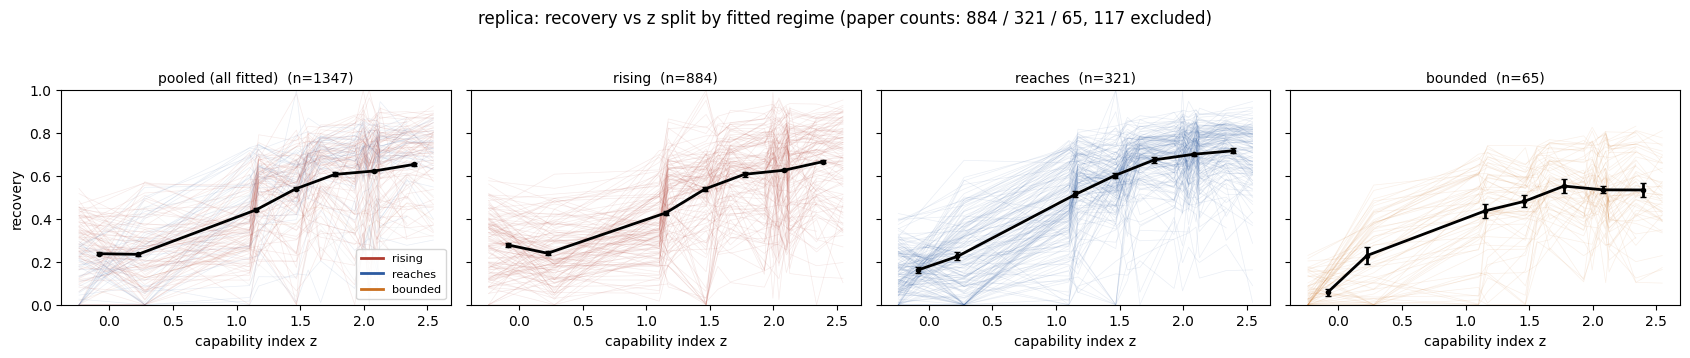

verdict counts: {'RISING': 884, 'REACHES': 321, 'NOISY': 77, 'BOUNDED': 65}


In [12]:
# 4.3b — the fitted-regime panels at full scale (replica of fig:scaling-envelopes
# unsupervised panel + fig:osl-regimes). Faint traces + binned mean ± 1.96 SE.
CURVES = []
for f in sorted(glob.glob("data/2026-07-07-osl-multi/curves_*.json")):
    dom = os.path.basename(f)[7:-5]
    for name, v in json.load(open(f)).items():
        if v.get("kind") != "bank": continue
        z, y = v.get("z"), v.get("y")
        if z and y and len(z) == len(y) and len(z) >= 3:
            CURVES.append((v.get("verdict"), dom, name, z, y))
def binned_mean(rows, B=9):
    zs = [a for _, _, _, z, _ in rows for a in z]
    edges = np.linspace(min(zs), max(zs), B + 1)
    out = []
    for i in range(B):
        vals = [min(1, max(0, b)) for _, _, _, z, y in rows
                for a, b in zip(z, y) if edges[i] <= a < edges[i + 1] + (1e-9 if i == B - 1 else 0)]
        if len(vals) >= 20:
            out.append(((edges[i] + edges[i + 1]) / 2, np.mean(vals), 1.96 * np.std(vals) / np.sqrt(len(vals))))
    return out
fig, axes = plt.subplots(1, 4, figsize=(17, 3.4), sharey=True)
panels = [("pooled (all fitted)", None)] + [(k.lower(), k) for k in ("RISING", "REACHES", "BOUNDED")]
for ax, (title, vd) in zip(axes, panels):
    rows = [r for r in CURVES if vd is None or r[0] == vd]
    for verd, _, _, z, y in rows[::max(1, len(rows) // 120)]:
        ax.plot(z, np.clip(y, 0, 1), color=RCOL.get(verd, "0.6"), alpha=.10, lw=.5)
    bm = binned_mean(rows)
    ax.errorbar([b[0] for b in bm], [b[1] for b in bm], yerr=[b[2] for b in bm],
                color="k", lw=2, marker="o", ms=3, capsize=2)
    ax.set_title(f"{title}  (n={len({(r[1], r[2]) for r in rows})})", fontsize=10)
    ax.set_xlabel("capability index z"); ax.set_ylim(0, 1)
axes[0].set_ylabel("recovery")
from matplotlib.lines import Line2D
axes[0].legend(handles=[Line2D([], [], color=c, lw=2, label=k.lower())
                        for k, c in RCOL.items() if k != "NOISY"], fontsize=8, loc="lower right")
plt.suptitle("replica: recovery vs z split by fitted regime (paper counts: 884 / 321 / 65, 117 excluded)", y=1.04)
plt.tight_layout(); plt.show()
print("verdict counts:", dict(Counter(r[0] for r in CURVES)))

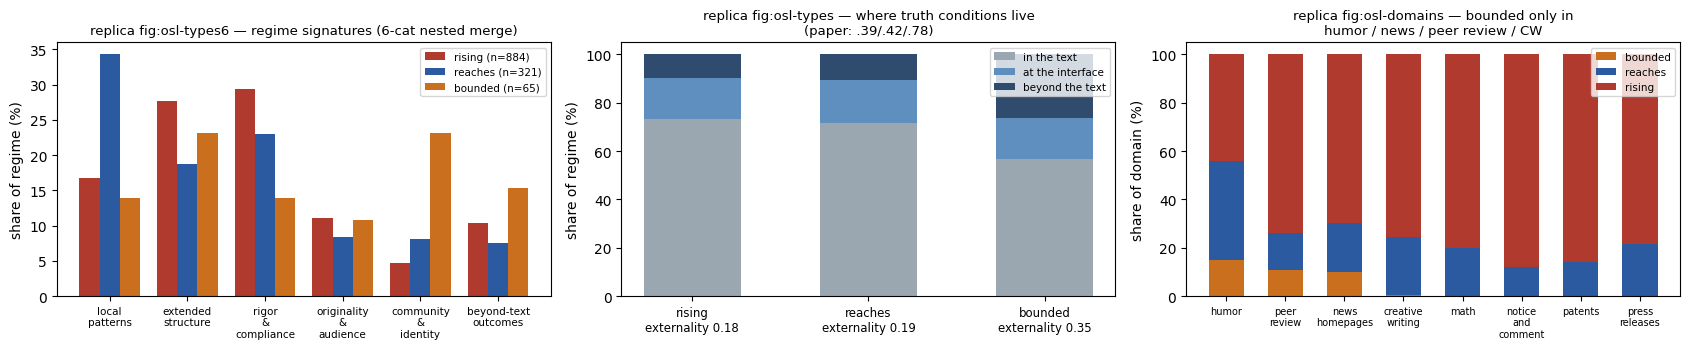

In [13]:
# 4.3c — what KIND of criterion lands in each regime (replica: fig:osl-types6 nested merge,
# coarse truth-condition axis, regime-by-domain).
T = json.load(open("../outputs/analyses/osl_metric_types_20260728.json"))
KEY = T["key"]
L12 = {i: (v["label"] if isinstance(v, dict) else v) for i, v in T["labels_12type"].items()}
L9 = {i: (v["label"] if isinstance(v, dict) else v) for i, v in T["labels"].items()}
M6 = {"COMPACT_DEVICE": "local patterns", "EXTENDED_STRUCTURE": "extended structure",
      "SURFACE_CHECK": "rigor & compliance", "ETHICS_HARM": "rigor & compliance",
      "VERIFICATION_SOURCING": "rigor & compliance", "LOGICAL_RIGOR": "rigor & compliance",
      "ORIGINALITY_NOVELTY": "originality & audience", "AUDIENCE_FIT": "originality & audience",
      "COMMUNITY_STANCE": "community & identity", "IDENTITY_PERSONA": "community & identity",
      "ECOSYSTEM_ARTIFACTS": "beyond-text outcomes", "RECEPTION_OUTCOME": "beyond-text outcomes"}
CATS6 = list(dict.fromkeys(M6[k] for k in M6))
REG = ["RISING", "REACHES", "BOUNDED"]
AX9 = {"MECHANICAL_CHECK": 0, "CRAFT_OPERATION": 0, "EVIDENCE_RIGOR": 0, "HOLISTIC_TASTE": 0,
       "AUDIENCE_FIT": 1, "COMMUNITY_TRANSFORM": 1,
       "IDENTITY_PERSONA": 2, "EXTERNAL_BUNDLE": 2, "RECEPTION_OUTCOME": 2}
fig, axes = plt.subplots(1, 3, figsize=(17, 3.6))
n_reg = {r: sum(1 for i in L12 if KEY[i]["verdict"] == r) for r in REG}
w = 0.26
for j, r in enumerate(REG):
    shares = [100 * sum(1 for i in L12 if KEY[i]["verdict"] == r and M6[L12[i]] == c) / n_reg[r] for c in CATS6]
    axes[0].bar(np.arange(len(CATS6)) + (j - 1) * w, shares, w, color=RCOL[r], label=f"{r.lower()} (n={n_reg[r]})")
axes[0].set_xticks(range(len(CATS6)))
axes[0].set_xticklabels([c.replace(" & ", " &\n").replace(" ", "\n", 1) for c in CATS6], fontsize=7.5)
axes[0].set_ylabel("share of regime (%)"); axes[0].legend(fontsize=7.5)
axes[0].set_title("replica fig:osl-types6 — regime signatures (6-cat nested merge)", fontsize=9.5)
AXN = ["in the text", "at the interface", "beyond the text"]
bot = np.zeros(len(REG)); ACOL = ["#9aa7b1", "#5f8fbf", "#2f4b6e"]
for a in (0, 1, 2):
    shares = [100 * sum(1 for i in L9 if KEY[i]["verdict"] == r and AX9[L9[i]] == a) / n_reg[r] for r in REG]
    axes[1].bar(range(len(REG)), shares, 0.55, bottom=bot, color=ACOL[a], label=AXN[a])
    bot += np.array(shares)
ext = {r: np.mean([AX9[L9[i]] / 2 for i in L9 if KEY[i]["verdict"] == r]) for r in REG}
axes[1].set_xticks(range(len(REG)))
axes[1].set_xticklabels([f"{r.lower()}\nexternality {ext[r]:.2f}" for r in REG], fontsize=8.5)
axes[1].set_ylabel("share of regime (%)"); axes[1].legend(fontsize=7.5)
axes[1].set_title("replica fig:osl-types — where truth conditions live\n(paper: .39/.42/.78)", fontsize=9.5)
dom_reg = {}
for i, k in KEY.items(): dom_reg.setdefault(k["dom"], Counter())[k["verdict"]] += 1
doms = sorted(dom_reg, key=lambda d: -dom_reg[d]["BOUNDED"] / max(1, sum(dom_reg[d].values())))
bot = np.zeros(len(doms))
for r in ("BOUNDED", "REACHES", "RISING"):
    shares = [100 * dom_reg[d][r] / sum(dom_reg[d].values()) for d in doms]
    axes[2].bar(range(len(doms)), shares, 0.6, bottom=bot, color=RCOL[r], label=r.lower())
    bot += np.array(shares)
axes[2].set_xticks(range(len(doms))); axes[2].set_xticklabels([d.replace("_", "\n") for d in doms], fontsize=7)
axes[2].set_ylabel("share of domain (%)"); axes[2].legend(fontsize=7.5)
axes[2].set_title("replica fig:osl-domains — bounded only in\nhumor / news / peer review / CW", fontsize=9.5)
plt.tight_layout(); plt.show()

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_57488/796452231.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data, labels=FAM3, showfliers=False, patch_artist=True)


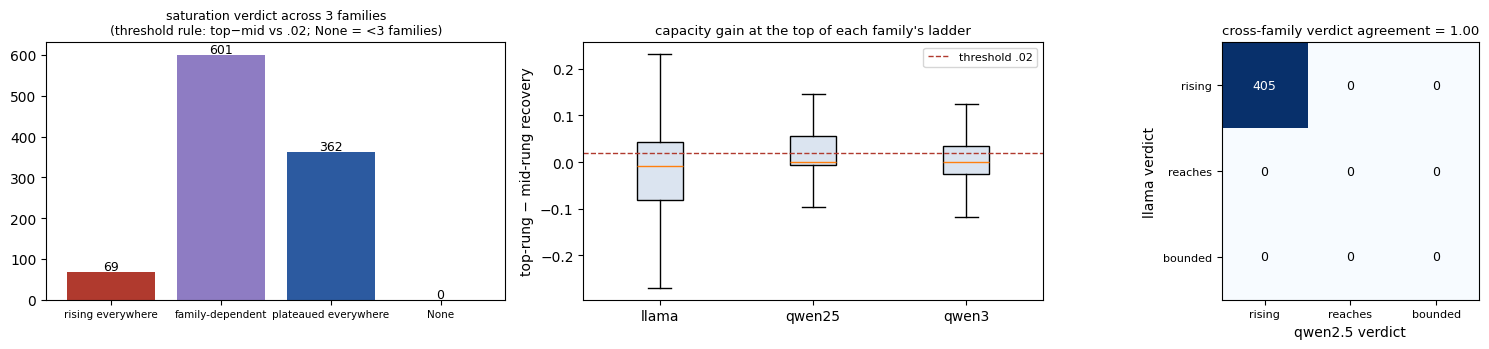

In [14]:
# 4.3d — the three-family saturation census: the verdict is a property of
# (construct, listener family), not the construct alone.
sg = Counter(satgroup(r) for r in FJ)
fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))
order = ["rising everywhere", "family-dependent", "plateaued everywhere", None]
axes[0].bar([str(o) for o in order], [sg[o] for o in order], color=["#b03a2e", "#8e7cc3", "#2c5aa0", "0.7"])
for i, o in enumerate(order): axes[0].text(i, sg[o] + 5, str(sg[o]), ha="center", fontsize=9)
axes[0].set_title("saturation verdict across 3 families\n(threshold rule: top−mid vs .02; None = <3 families)", fontsize=9)
axes[0].tick_params(axis="x", labelsize=7.5)
FAM3 = ["llama", "qwen25", "qwen3"]
data = [[r["top_minus_mid"][f] for r in FJ if r["top_minus_mid"].get(f) is not None] for f in FAM3]
bp = axes[1].boxplot(data, labels=FAM3, showfliers=False, patch_artist=True)
for p in bp["boxes"]: p.set_facecolor("#dbe4f0")
axes[1].axhline(0.02, color="#b03a2e", ls="--", lw=1, label="threshold .02")
axes[1].set_ylabel("top-rung − mid-rung recovery"); axes[1].legend(fontsize=8)
axes[1].set_title("capacity gain at the top of each family's ladder", fontsize=9.5)
VN = ["RISING", "REACHES", "BOUNDED"]
M = np.zeros((3, 3))
for r in FJ:
    a, b = r["verdict3"].get("llama"), r["verdict3"].get("qwen25")
    if a in VN and b in VN: M[VN.index(a), VN.index(b)] += 1
im = axes[2].imshow(M, cmap="Blues")
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, int(M[i, j]), ha="center", va="center",
                     color="w" if M[i, j] > M.max() / 2 else "k", fontsize=9)
axes[2].set_xticks(range(3)); axes[2].set_xticklabels([v.lower() for v in VN], fontsize=8)
axes[2].set_yticks(range(3)); axes[2].set_yticklabels([v.lower() for v in VN], fontsize=8)
axes[2].set_xlabel("qwen2.5 verdict"); axes[2].set_ylabel("llama verdict")
axes[2].set_title(f"cross-family verdict agreement = {np.trace(M)/M.sum():.2f}", fontsize=9.5)
plt.tight_layout(); plt.show()

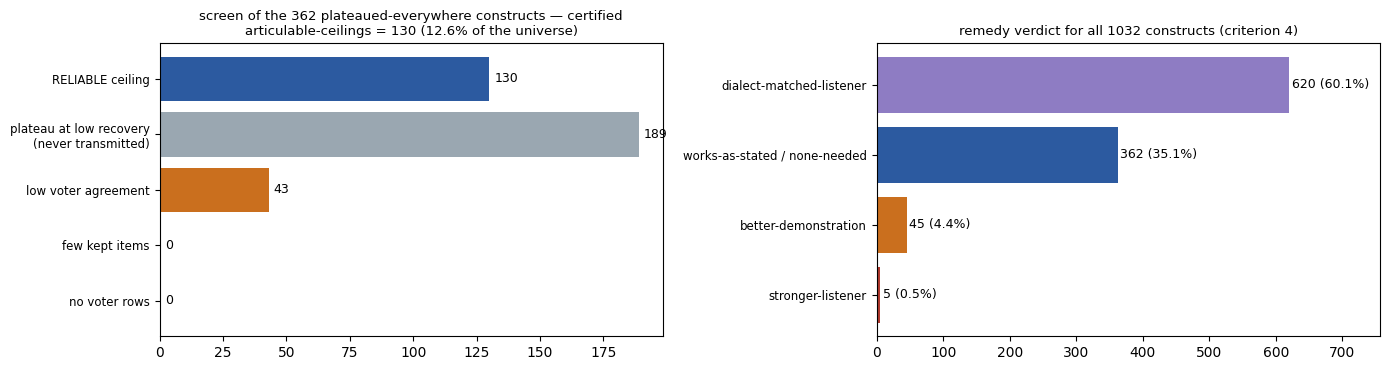

A flat curve against a noisy reference is NOT a ceiling — only 12.6% of the universe
is a certified ceiling; the modal remedy is a dialect-matched listener, not more capability.


In [15]:
# 4.3e — which plateaus are REAL (reliability screen) + every construct's remedy verdict.
RF = json.load(open("../outputs/analyses/reliability_filter_v1/reliability_filter_v1.json"))["rows"]
VT = json.load(open("../outputs/analyses/verdict_table_v1/verdict_table_v1.json"))["rows"]
def fail_mode(r):
    if r["status"] != "ok": return "no voter rows"
    if r["reliable_plateau"]: return "RELIABLE ceiling"
    if r["agreement"] < .70: return "low voter agreement"
    if r["kept_n"] < 150: return "few kept items"
    return "plateau at low recovery\n(never transmitted)"
fm = Counter(fail_mode(r) for r in RF)
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
keys = ["RELIABLE ceiling", "plateau at low recovery\n(never transmitted)",
        "low voter agreement", "few kept items", "no voter rows"]
cols = ["#2c5aa0", "#9aa7b1", "#ca6f1e", "#caa46f", "0.75"]
axes[0].barh(range(len(keys)), [fm.get(k, 0) for k in keys], color=cols)
for i, k in enumerate(keys): axes[0].text(fm.get(k, 0) + 2, i, str(fm.get(k, 0)), va="center", fontsize=9)
axes[0].set_yticks(range(len(keys))); axes[0].set_yticklabels(keys, fontsize=8.5)
axes[0].invert_yaxis()
axes[0].set_title(f"screen of the {len(RF)} plateaued-everywhere constructs — certified\n"
                  f"articulable-ceilings = {fm.get('RELIABLE ceiling',0)} ({100*fm.get('RELIABLE ceiling',0)/1032:.1f}% of the universe)", fontsize=9.5)
rem = Counter(r["remedy"] for r in VT)
labels, vals = zip(*rem.most_common())
axes[1].barh(range(len(labels)), vals, color=["#8e7cc3", "#2c5aa0", "#ca6f1e", "#b03a2e", "0.6", "0.8"][:len(labels)])
for i, v in enumerate(vals): axes[1].text(v + 4, i, f"{v} ({100*v/len(VT):.1f}%)", va="center", fontsize=9)
axes[1].set_yticks(range(len(labels))); axes[1].set_yticklabels(labels, fontsize=8.5)
axes[1].invert_yaxis(); axes[1].set_xlim(0, max(vals) * 1.22)
axes[1].set_title(f"remedy verdict for all {len(VT)} constructs (criterion 4)", fontsize=9.5)
plt.tight_layout(); plt.show()
print("A flat curve against a noisy reference is NOT a ceiling — only 12.6% of the universe")
print("is a certified ceiling; the modal remedy is a dialect-matched listener, not more capability.")

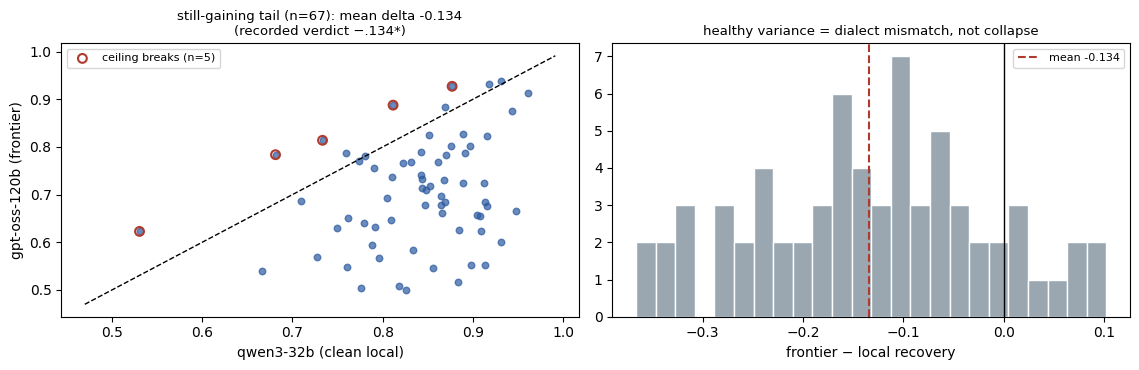

Under the LOCAL-dialect reference, frontier capability does not uncap the tail: the rising
asymptote stays unidentified — a listener-DIALECT bound, not a z bound.


In [16]:
# 4.3f — the frontier does not de-censor the still-gaining tail (69 constructs; x = best
# clean local comparator qwen3-32b, y = gpt-oss-120b, both vs the local 2-voter reference).
DH = {r["b"]: r for r in json.load(open(f"{D}/analyses/decensor_harvest_v1.json"))}
TAIL = [tuple(r) if isinstance(r, list) else (r["task"], r["name"])
        for r in json.load(open(f"{D}/flips/decensor_tail_v1.json"))]
xs, ys = [], []
for t, n in TAIL:
    r = DH.get(n)
    if r and r.get("qwen3-32b") is not None and r.get("gptoss") is not None:
        xs.append(r["qwen3-32b"]); ys.append(r["gptoss"])
xs, ys = np.array(xs), np.array(ys); d = ys - xs
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].scatter(xs, ys, s=22, alpha=.7, color="#2c5aa0")
lim = [min(xs.min(), ys.min()) - .03, max(xs.max(), ys.max()) + .03]
axes[0].plot(lim, lim, "k--", lw=1)
brk = d >= .05
axes[0].scatter(xs[brk], ys[brk], s=40, facecolors="none", edgecolors="#b03a2e", lw=1.5,
                label=f"ceiling breaks (n={brk.sum()})")
axes[0].set_xlabel("qwen3-32b (clean local)"); axes[0].set_ylabel("gpt-oss-120b (frontier)")
axes[0].legend(fontsize=8)
axes[0].set_title(f"still-gaining tail (n={len(xs)}): mean delta {d.mean():+.3f}\n(recorded verdict −.134*)", fontsize=9.5)
axes[1].hist(d, bins=24, color="#9aa7b1", edgecolor="w")
axes[1].axvline(0, color="k", lw=1); axes[1].axvline(d.mean(), color="#b03a2e", lw=1.5, ls="--", label=f"mean {d.mean():+.3f}")
axes[1].set_xlabel("frontier − local recovery"); axes[1].legend(fontsize=8)
axes[1].set_title("healthy variance = dialect mismatch, not collapse", fontsize=9.5)
plt.tight_layout(); plt.show()
print("Under the LOCAL-dialect reference, frontier capability does not uncap the tail: the rising")
print("asymptote stays unidentified — a listener-DIALECT bound, not a z bound.")

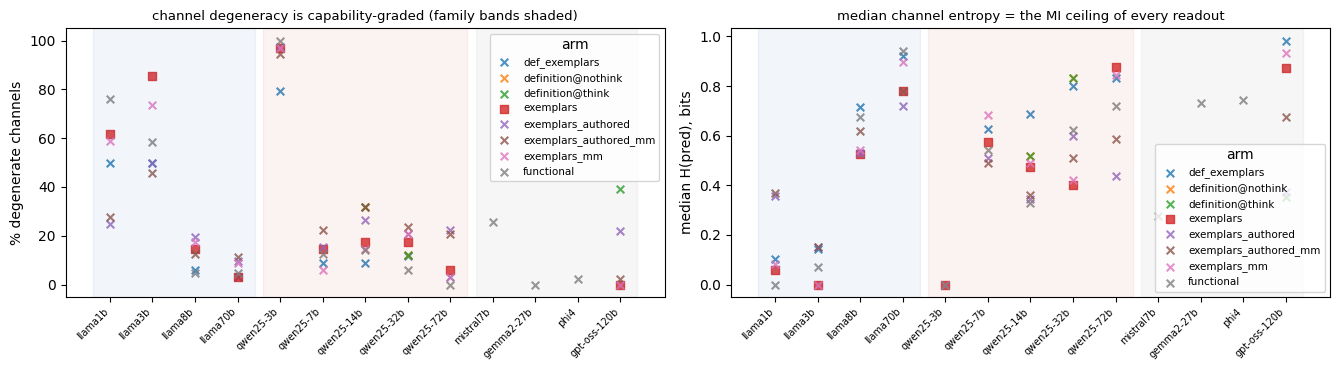

Small-z recovery floors are CHANNEL COLLAPSE (near-constant predictions), not construct absence.


In [17]:
# 4.3g — instrument health: the MI upper-bound census. Dot plot per receiver (grouped by
# family, no cross-family lines): % degenerate channels and median H(pred) — the hard MI
# ceiling of every readout at that receiver.
MI = pd.DataFrame(json.load(open(f"{D}/analyses/mi_upper_census_v2.json"))["rows"])
ORDER = [e for fam in FAMS.values() for e in fam if e in set(MI["ex"])]
sub = MI[MI["ex"].isin(ORDER)]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.8))
ms = {"definition": "o", "exemplars": "s", "name": "^", "dossier": "D"}
for arm, g in sub.groupby("arm"):
    st_ = g.groupby("ex").agg(deg=("degenerate", "mean"), H=("H_pred", "median")).reindex(ORDER)
    x = np.arange(len(ORDER))
    axes[0].scatter(x, 100 * st_["deg"], marker=ms.get(arm, "x"), s=30, label=arm, alpha=.8)
    axes[1].scatter(x, st_["H"], marker=ms.get(arm, "x"), s=30, label=arm, alpha=.8)
for ax in axes:
    ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER, rotation=45, ha="right", fontsize=7)
    for fam, exes in FAMS.items():
        idx = [ORDER.index(e) for e in exes if e in ORDER]
        if idx: ax.axvspan(min(idx) - .4, max(idx) + .4, color=FCOL[fam], alpha=.06)
axes[0].set_ylabel("% degenerate channels"); axes[0].legend(fontsize=7.5, title="arm")
axes[0].set_title("channel degeneracy is capability-graded (family bands shaded)", fontsize=9.5)
axes[1].set_ylabel("median H(pred), bits"); axes[1].legend(fontsize=7.5, title="arm")
axes[1].set_title("median channel entropy = the MI ceiling of every readout", fontsize=9.5)
plt.tight_layout(); plt.show()
print("Small-z recovery floors are CHANNEL COLLAPSE (near-constant predictions), not construct absence.")

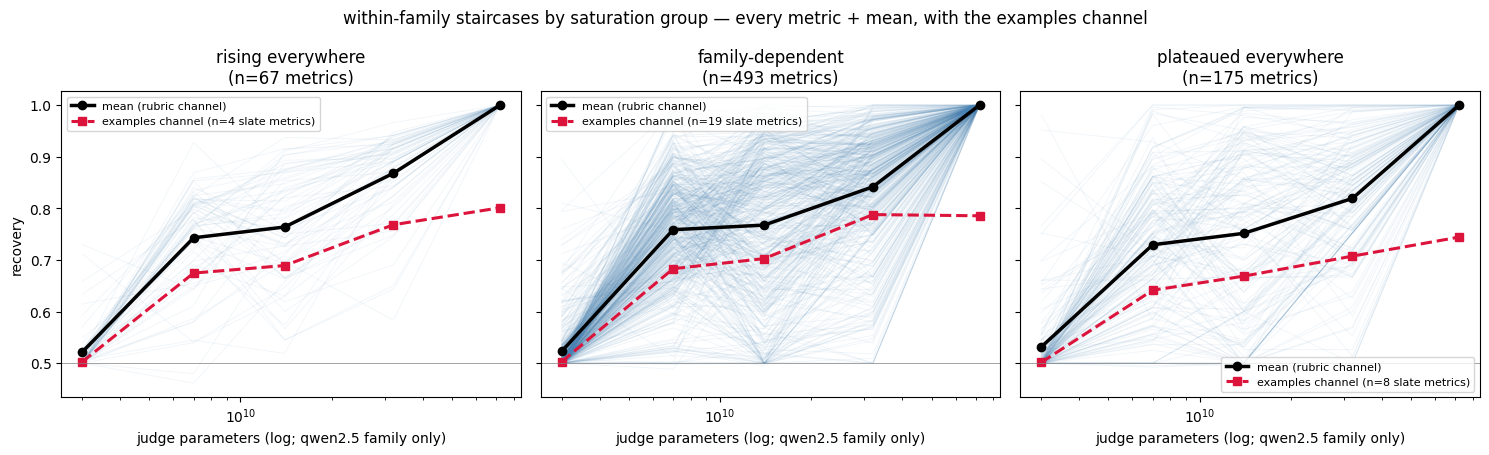

{'rising everywhere': 67, 'family-dependent': 493, 'plateaued everywhere': 175}


In [18]:
# 4.3h — within-family staircases by saturation group (qwen2.5 family; a connected line is
# meaningful HERE because every point is the same family), with the examples channel overlay.
QF = ["qwen25-3b", "qwen25-7b", "qwen25-14b", "qwen25-32b", "qwen25-72b"]
QP = [3e9, 7e9, 14e9, 32e9, 72e9]
def crowd(task, ex):
    d = {}
    if task == "humor":
        d.update(lp(f"{D}/crowd_panels/mbar285_{ex}.npz")); d.update(lp(f"{D}/crowd_panels/mbar2_humor_sup_{ex}.npz"))
    else:
        d.update(lp(f"{D}/crowd_panels/mbar2_{task}_{ex}.npz"))
    return d
CR = {t: {ex: crowd(t, ex) for ex in QF + ["llama70b"]} for t in TASKS}
def cref(task, base):
    votes = []
    for ex in ("llama70b", "qwen25-72b"):
        r = CR[task].get(ex, {}).get(base)
        if r is not None: votes.append((np.asarray(r, float) > .5).astype(float))
    if len(votes) < 2: return None
    m = np.stack(votes).mean(0)
    return np.where(m > .5, 1, np.where(m < .5, 0, -1))
curves = {}
for r in FJ:
    t, b = r["task"], r["name"]
    g = GROUP[(t, b)]
    if g is None: continue
    lab = cref(t, b)
    if lab is None: continue
    ys = []
    for ex in QF:
        v = CR[t].get(ex, {}).get(b)
        ys.append(balanced(np.asarray(v, float), lab) if v is not None else None)
    if sum(y is not None for y in ys) >= 4:
        curves.setdefault(g, []).append((t, b, ys))
lad = {ex: lp(f"{D}/flips/mbar_flipladder_{ex}.npz") for ex in QF}
ex_curves = {}
for key in lad[QF[-1]]:
    if "functional_llama70b_frontier" not in key: continue
    t, rest = key.split("|", 1)
    b = rest.split("||")[0]
    g = GROUP.get((t, b))
    if g is None or t not in ZTASKS: continue
    lab = ref_for(t, b)
    if lab is None: continue
    ys = []
    for ex in QF:
        r = lad[ex].get(key)
        ys.append(balanced(np.asarray(r, float), lab) if r is not None else None)
    if sum(y is not None for y in ys) >= 4:
        ex_curves.setdefault(g, []).append(ys)
GORDER = ["rising everywhere", "family-dependent", "plateaued everywhere"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, g in zip(axes, GORDER):
    cs = curves.get(g, [])
    for t, b, ys in cs:
        xs_ = [p for p, y in zip(QP, ys) if y is not None]
        ax.semilogx(xs_, [y for y in ys if y is not None], color="steelblue", alpha=.07, lw=.7)
    mean = [np.mean([ys[i] for _, _, ys in cs if ys[i] is not None]) for i in range(len(QF))]
    ax.semilogx(QP, mean, color="k", lw=2.5, marker="o", label="mean (rubric channel)")
    ec = ex_curves.get(g, [])
    if ec:
        em = [np.mean([ys[i] for ys in ec if ys[i] is not None]) for i in range(len(QF))]
        ax.semilogx(QP, em, color="crimson", lw=2.2, ls="--", marker="s",
                    label=f"examples channel (n={len(ec)} slate metrics)")
    ax.set_title(f"{g}\n(n={len(cs)} metrics)"); ax.axhline(.5, color="gray", lw=.5)
    ax.set_xlabel("judge parameters (log; qwen2.5 family only)"); ax.legend(fontsize=8)
axes[0].set_ylabel("recovery")
fig.suptitle("within-family staircases by saturation group — every metric + mean, with the examples channel")
plt.tight_layout(); plt.show()
print({g: len(curves.get(g, [])) for g in GORDER})

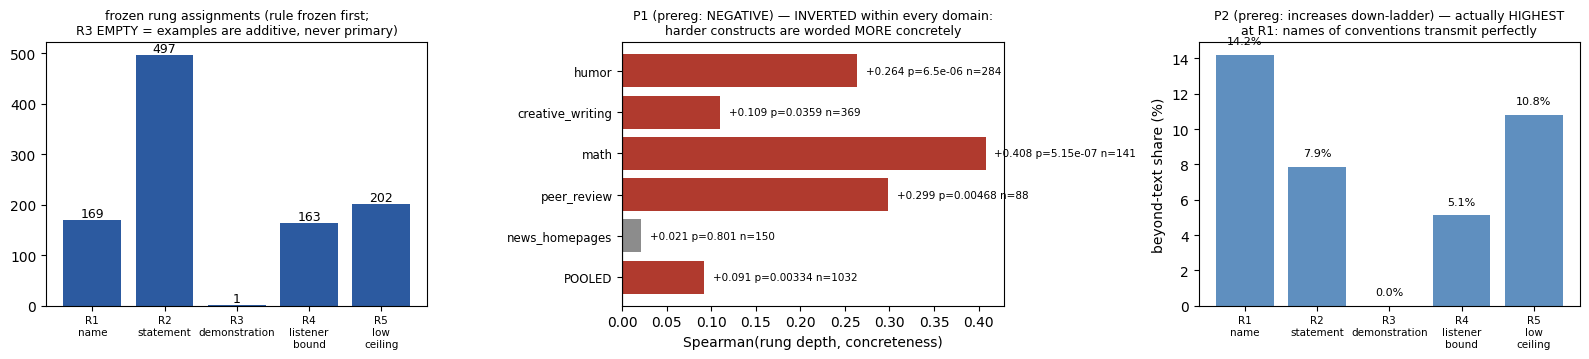

PREREG LANDING (frozen zone 3): the operational ladder does not reduce to lexical abstractness.


In [19]:
# 4.3i — the operational ladder (criterion 5): frozen rungs, then the preregistered
# abstractness tests. P1 uses the AUDITED instrument (expanded function-word list +
# suffix lemmatizer + Brysbaert norms); committed reference values 2026-08-11:
# humor +.264*** / math +.397*** / peer +.287** / CW +.114* / news +.010 n.s.; pooled +.092.
LAD = json.load(open("../outputs/analyses/ladder_p123_v1/ladder_p123_v1.json"))["rows"]
RUNGS = ["R1-name", "R2-statement", "R3-demonstration", "R4-listener-bound", "R5-low-ceiling"]
CONC = {}
for rec in csv.DictReader(open(f"{D}/analyses/brysbaert_concreteness.csv"), delimiter="\t"):
    try: CONC[rec["Word"].lower()] = float(rec["Conc.M"])
    except (ValueError, KeyError): pass
FUNC = set(('''the a an and or but nor of to in for with on by at from into over under as that this
these those it its they them their there here is are was were be been being am do does did done
have has had having will would shall should can could may might must not no yes if then else when
while which who whom whose what where why how all any some none each every either neither both few
many much more most other another such only own same so than too very just also again further once
about against between through during before after above below up down out off again very'''.split()))
def lemma(w):
    for suf, rep in (("ies", "y"), ("es", ""), ("s", ""), ("ing", ""), ("ing", "e"), ("ed", ""), ("ed", "e")):
        if w.endswith(suf) and len(w) > len(suf) + 2:
            cand = w[:len(w) - len(suf)] + rep
            if cand in CONC: return cand
    return w
DEFS = {}
for t in TASKS:
    for m in json.load(open(f"{D}/code_metrics/defs_{t}.json")): DEFS[(t, m["name"])] = m["definition"]
def conc_of(text):
    toks = [w for w in re.findall(r"[a-z]+", text.lower()) if w not in FUNC]
    vals = [CONC[lemma(w)] for w in toks if lemma(w) in CONC]
    return float(np.mean(vals)) if len(vals) >= 5 else None
for r in LAD:
    r["conc2"] = conc_of(r["name"] + " " + DEFS.get((r["task"], r["name"]), ""))
fig, axes = plt.subplots(1, 3, figsize=(16, 3.7))
rc = Counter(r["rung"] for r in LAD)
axes[0].bar(range(len(RUNGS)), [rc[g] for g in RUNGS], color="#2c5aa0")
for i, g in enumerate(RUNGS): axes[0].text(i, rc[g] + 6, str(rc[g]), ha="center", fontsize=9)
axes[0].set_xticks(range(len(RUNGS))); axes[0].set_xticklabels([g.replace("-", "\n") for g in RUNGS], fontsize=7.5)
axes[0].set_title("frozen rung assignments (rule frozen first;\nR3 EMPTY = examples are additive, never primary)", fontsize=9)
ok = [r for r in LAD if r["conc2"] is not None]
rows, labels = [], []
for t in TASKS:
    s_ = [r for r in ok if r["task"] == t]
    rho, p = sps.spearmanr([r["rung_idx"] for r in s_], [r["conc2"] for r in s_])
    rows.append((rho, p, len(s_))); labels.append(t)
prho, pp = sps.spearmanr([r["rung_idx"] for r in ok], [r["conc2"] for r in ok])
rows.append((prho, pp, len(ok))); labels.append("POOLED")
for i, ((rho, p, n), lb) in enumerate(zip(rows, labels)):
    axes[1].barh(i, rho, color="#b03a2e" if p < .05 else "0.55")
    axes[1].text(rho + (.01 if rho >= 0 else -.01), i, f"{rho:+.3f} p={p:.3g} n={n}",
                 va="center", ha="left" if rho >= 0 else "right", fontsize=7.5)
axes[1].axvline(0, color="k", lw=.8)
axes[1].set_yticks(range(len(labels))); axes[1].set_yticklabels(labels, fontsize=8.5)
axes[1].invert_yaxis(); axes[1].set_xlabel("Spearman(rung depth, concreteness)")
axes[1].set_title("P1 (prereg: NEGATIVE) — INVERTED within every domain:\nharder constructs are worded MORE concretely", fontsize=9)
sh = []
for g in RUNGS:
    s_ = [r for r in LAD if r["rung"] == g and r["axis"] is not None]
    sh.append(100 * np.mean([r["axis"] == 2 for r in s_]) if s_ else np.nan)
axes[2].bar(range(len(RUNGS)), sh, color="#5f8fbf")
for i, v in enumerate(sh):
    if np.isfinite(v): axes[2].text(i, v + .6, f"{v:.1f}%", ha="center", fontsize=8)
axes[2].set_xticks(range(len(RUNGS))); axes[2].set_xticklabels([g.replace("-", "\n") for g in RUNGS], fontsize=7.5)
axes[2].set_ylabel("beyond-text share (%)")
axes[2].set_title("P2 (prereg: increases down-ladder) — actually HIGHEST\nat R1: names of conventions transmit perfectly", fontsize=9)
plt.tight_layout(); plt.show()
print("PREREG LANDING (frozen zone 3): the operational ladder does not reduce to lexical abstractness.")

## Appendix — supervised anchors (context only; not part of the unsupervised story)

Table 1 rows-of-record and the supervised Qwen3 ladder, for cross-reference with §3 of the paper.

,benchmark,GEPA,GEPA+Merge,MIPROv2,eps-cert (M_omega),Delta vs GEPA
0,HotpotQA,0.411,0.400,0.439,0.646,+.235***
1,HoVer,0.471,0.517,NaN,0.557,"+.086*** (re-mint at 10,110-call parity: +.066..."
2,LiveBench,0.699,0.688,0.677,0.705,+.006 n.s.
3,IFBench,0.403,0.411,0.383,0.443,+.040**
4,AIME,0.385,0.373,0.323,0.392,+.007 n.s.
5,PUPA,0.883,NaN,NaN,0.882,-.001 — RE-MINT IN FLIGHT on sk1 2026-08-11 (f...


,task,corrected rho (MI vs judge-vs-silver AUC)
0,peer-review,0.68
1,code-review,0.62
2,creative-writing,0.61
3,math,0.56
4,press-releases,0.50
5,humor,0.45


Table 2 design (HELD result — the paper's validity anchor): WITHIN-metric across its own
prompt forms; attenuation-corrected; code-review confirmed out-of-sample vs a prereg stratum.


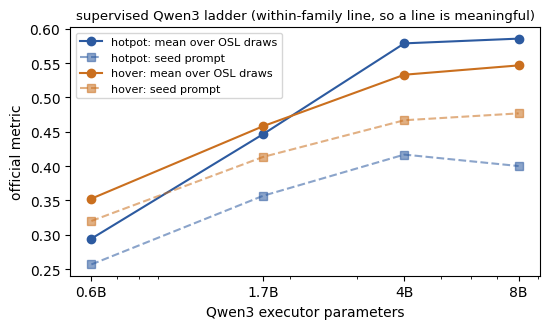

In [20]:
# A.1 — Table 1 + Table 2 as printed (with live re-mint status), and the supervised ladder.
import statistics as st
t1 = pd.DataFrame([
    ["HotpotQA", .411, .400, .439, .646, "+.235***"],
    ["HoVer", .471, .517, None, .557, "+.086*** (re-mint at 10,110-call parity: +.066* [.040,.093])"],
    ["LiveBench", .699, .688, .677, .705, "+.006 n.s."],
    ["IFBench", .403, .411, .383, .443, "+.040**"],
    ["AIME", .385, .373, .323, .392, "+.007 n.s."],
    ["PUPA", .883, None, None, .882, "-.001 — RE-MINT IN FLIGHT on sk1 2026-08-11 (fresh same-session: GEPA .9062 / MIPROv2 .8831 / Merge .8442; M_omega pending)"],
], columns=["benchmark", "GEPA", "GEPA+Merge", "MIPROv2", "eps-cert (M_omega)", "Delta vs GEPA"])
display(t1)
t2 = pd.DataFrame([["peer-review", .68], ["code-review", .62], ["creative-writing", .61],
                   ["math", .56], ["press-releases", .50], ["humor", .45]],
                  columns=["task", "corrected rho (MI vs judge-vs-silver AUC)"])
display(t2)
print("Table 2 design (HELD result — the paper's validity anchor): WITHIN-metric across its own")
print("prompt forms; attenuation-corrected; code-review confirmed out-of-sample vs a prereg stratum.")
PAR = {"Qwen3-0.6B": 0.6, "Qwen3-1.7B": 1.7, "Qwen3-4B": 4.0, "Qwen3-8B": 8.0}
BC = {"hotpot": "#2c5aa0", "hover": "#ca6f1e"}
pts = {}
for f in sorted(glob.glob("../datasets/prompt-optimality-test/runs/osl_*.json")):
    d = json.load(open(f))
    b, mn = d.get("bench"), d.get("model")
    if b not in BC or mn not in PAR: continue
    dr = [x["score"] for x in (d.get("draws") or []) if x.get("score") is not None]
    if d.get("init") is None or len(dr) < 20: continue
    pts.setdefault(b, []).append((PAR[mn], d["init"], st.mean(dr)))
fig, ax = plt.subplots(figsize=(5.6, 3.4))
for b, rows in sorted(pts.items()):
    rows.sort()
    ax.plot([r[0] for r in rows], [r[2] for r in rows], "-o", color=BC[b], label=f"{b}: mean over OSL draws")
    ax.plot([r[0] for r in rows], [r[1] for r in rows], "--s", color=BC[b], alpha=.55, label=f"{b}: seed prompt")
ax.set_xscale("log"); ax.set_xticks([0.6, 1.7, 4, 8]); ax.set_xticklabels(["0.6B", "1.7B", "4B", "8B"])
ax.set_xlabel("Qwen3 executor parameters"); ax.set_ylabel("official metric")
ax.set_title("supervised Qwen3 ladder (within-family line, so a line is meaningful)", fontsize=9.5)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

---
### Canonical artifacts (quote these, not notebook recomputations)

| claim | artifact |
|---|---|
| unit codability labels (3,458 units, 6/6 anchors ×3 crews) | `outputs/articulation_story_20260810/code_metrics/unit_codability_<task>.json` |
| channel arms + references (zxa panels) | `outputs/articulation_story_20260810/zxa_panels/` |
| examples ledgers (two receivers, mm controls) | `.../analyses/v3sets_ledger_v1.json` (certified deltas: content +.0135\* qwen / anchoring +.0628\* gptoss) |
| blind construct categories (30/114/59) | `.../analyses/metric_categories_blind_v1.json` |
| frontier limit (gate/gap, both receivers) | `.../analyses/frontier_limit_humor_v2.json` |
| OSL fit verdicts + curves (RISING/REACHES/BOUNDED rule: AICc logistic-vs-linear + planted-ref comparison, see 4.3 header) | `notebooks/data/2026-07-07-osl-multi/{curves,laws}_*.json`; fit code `methods/metric_implementer/experiments/osl_staged_20260808/panel_analysis.py` |
| three-family census (threshold rule top−mid .02) | `.../analyses/family_verdict_join_v1.json` |
| reliability screen thresholds + rows | `outputs/analyses/reliability_filter_v1/` |
| remedy verdicts (criterion 4) | `outputs/analyses/verdict_table_v1/` |
| de-censor harvest + tail | `.../analyses/decensor_harvest_v1.json`, `.../flips/decensor_tail_v1.json` |
| MI census | `.../analyses/mi_upper_census_v2.json` |
| frozen rungs + P1/P2 (committed audit values in notes 2026-08-11) | `outputs/analyses/ladder_p123_v1/`; `notes/2026-08-05__direction12-battery-plan.md` |
| 9/12-type labels (κ=.75) | `outputs/analyses/osl_metric_types_20260728.json` |
| change-types (HB174) | parsed from `latex/paper-2__articulation-upper-bounds/figs/gen_change_types.tex` |
| Table-1 rows-of-record | `notes/2026-07-19__gepa-consolidation-and-momega-upgrade-plan.md` (FINAL TABLE 1 + HB204) |

**Open coverage items**: unit-codability labels for notice-and-comment / press-releases / patents (~272 definitions — labeling wave available on request); PUPA re-mint completing on sk1.